### Задание:
**Задача 1**
Изучите таблицу users_info, содержащую информацию о пользователях. Провести разведочный анализ: проверить типы данных, очистить от пропусков, найти и убрать выбросы по возрасту (с помощью IQR). Построить визуализацию распределения возрастов.


**Задача 2** 
Проанализируйте распределение пользователей по полу и городам:
+ Рассчитайте количество пользователей по каждому полу и городу.
+ Используйте pivot_table, чтобы представить данные:
— города в строках,
— пол в столбцах.
+ Для каждого города рассчитайте долю женщин среди всех пользователей.
+ Постройте столбчатую диаграмму (bar chart), чтобы сравнить долю женщин в разных городах.Какой город отличается от остальных?

**Задача 3** Сегментация

Загрузите таблицу payments_monthly.csv с платежами, очищенными от выбросов и сгруппированными по месяцам.
Рассчитайте среднее количество тренировок в месяц для каждого пользователя.
+ Разделите пользователей на три группы по уровню активности:
— мало (редко тренируются),
— средне,
— много (тренируются часто).
+ Посчитайте, сколько пользователей входит в каждую из этих групп.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
users_info = pd.read_csv('users_info.csv')
users_info.head()

,id_user,city,age,gender
0,1000,СПб,44.0,female
1,1001,Москва,35.0,female
2,1002,Москва,34.0,male
3,1003,Москва,NaN,NaN
4,1004,Екатеринбург,60.0,male


### Задача 1. EDA

In [3]:
users_info.shape

(1000, 4)

In [4]:
users_info.dtypes

id_user      int64
city        object
age        float64
gender      object
dtype: object

In [5]:
users_info.isnull().sum()

id_user     0
city        0
age        88
gender     89
dtype: int64

In [6]:
# 89 нулов на 1000
# Удаляю все нулы
users_info_without_nulls = users_info.dropna()
users_info_without_nulls.head(30)

,id_user,city,age,gender
0,1000,СПб,44.0,female
1,1001,Москва,35.0,female
2,1002,Москва,34.0,male
4,1004,Екатеринбург,60.0,male
5,1005,СПб,35.0,female
6,1006,Казань,46.0,female
7,1007,Москва,58.0,female
8,1008,СПб,53.0,female
9,1009,Москва,22.0,female
10,1010,Москва,47.0,female


In [7]:
# IQR по age
Q1 = np.percentile(users_info_without_nulls['age'], 25)
Q3 = np.percentile(users_info_without_nulls['age'], 75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5*IQR
upper_bound = Q3 + 1.5*IQR
print(IQR)
print(lower_bound)
print(upper_bound)
print(users_info_without_nulls['age'].mean())

23.0
-6.5
85.5
39.41965317919075


In [8]:
users_info_without_nulls['age'].describe()

count    865.000000
mean      39.419653
std       13.774501
min       18.000000
25%       28.000000
50%       37.000000
75%       51.000000
max       65.000000
Name: age, dtype: float64

In [9]:
# удаляю выбросы из таблицы
users_info_normalized = users_info_without_nulls.loc[(users_info_without_nulls['age'] < upper_bound) & (users_info_without_nulls['age'] > lower_bound)].copy()
users_info_normalized

,id_user,city,age,gender
0,1000,СПб,44.0,female
1,1001,Москва,35.0,female
2,1002,Москва,34.0,male
4,1004,Екатеринбург,60.0,male
5,1005,СПб,35.0,female
...,...,...,...,...
993,1993,СПб,36.0,male
994,1994,Казань,46.0,male
995,1995,Москва,43.0,female
997,1997,СПб,58.0,male


<Axes: xlabel='age', ylabel='Count'>

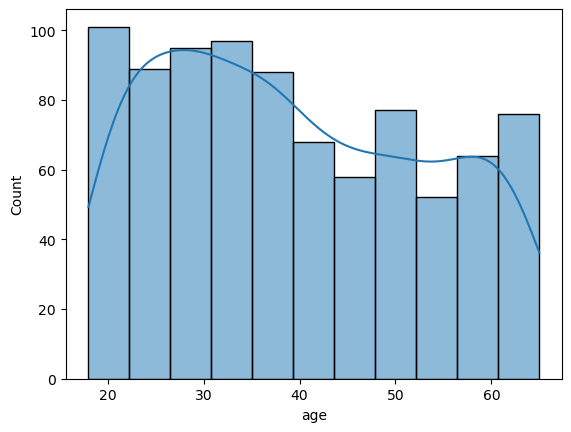

In [10]:
# распределение возрастов пользователей (гистограмма)
sns.histplot(users_info_normalized['age'], kde = True)

### Задача 2. Доля пользователей-женщин по городам

In [11]:
users_city = users_info_normalized.groupby('city').agg(cnt_users = ('id_user', 'count')).reset_index()
users_city

,city,cnt_users
0,Екатеринбург,133
1,Казань,130
2,Москва,325
3,СПб,277


In [12]:
users_gender = users_info_normalized.groupby('gender').agg(cnt_users = ('id_user', 'count')).reset_index()
users_gender

,gender,cnt_users
0,female,451
1,male,414


In [13]:
users_city_gender = users_info_normalized.groupby(['city', 'gender']).agg(cnt_users = ('id_user', 'count')).reset_index()
users_city_gender

,city,gender,cnt_users
0,Екатеринбург,female,55
1,Екатеринбург,male,78
2,Казань,female,53
3,Казань,male,77
4,Москва,female,220
5,Москва,male,105
6,СПб,female,123
7,СПб,male,154


In [14]:
pivot_users = pd.pivot_table(users_city_gender, \
                             values = 'cnt_users', \
                             index = 'city', \
                             columns = 'gender', \
                             aggfunc = 'sum', \
                             fill_value = 0).reset_index()
pivot_users

gender,city,female,male
0,Екатеринбург,55,78
1,Казань,53,77
2,Москва,220,105
3,СПб,123,154


In [15]:
pivot_users.columns = ['city', 'cnt_female', 'cnt_male']
pivot_users['total'] = pivot_users['cnt_female'] + pivot_users['cnt_male']
pivot_users['female_share'] = pivot_users ['cnt_female'] / pivot_users['total']
pivot_users

,city,cnt_female,cnt_male,total,female_share
0,Екатеринбург,55,78,133,0.413534
1,Казань,53,77,130,0.407692
2,Москва,220,105,325,0.676923
3,СПб,123,154,277,0.444043


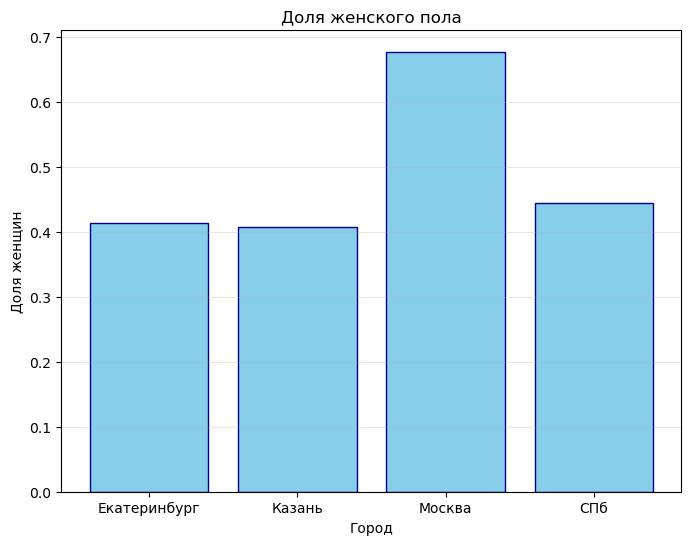

In [16]:
plt.figure(figsize=(8, 6))
plt.bar(pivot_users['city'], pivot_users['female_share'], color='skyblue', edgecolor='navy')
plt.title('Доля женского пола')
plt.xlabel('Город')
plt.ylabel('Доля женщин')
plt.grid(axis='y', alpha=0.3)
plt.show()

In [17]:
# Только в Москве женщин больше чем мужчин, значительно

### Задача 3. Делим пользователей на бины

In [18]:
pay_mon = pd.read_csv('payments_monthly.csv')
pay_mon.head()

,id_user,mon,cnt_group,cnt_indiv,sum_group,sum_indiv,cnt_total,sum_total
0,1000,2023-03,0,2,0,3600,2,3600
1,1000,2023-04,0,4,0,7200,4,7200
2,1000,2023-05,0,4,0,6400,4,6400
3,1000,2023-06,0,2,0,3600,2,3600
4,1000,2023-07,0,4,0,7200,4,7200


In [19]:
avg_workouts = round(pay_mon.groupby('id_user')['cnt_total'].mean().reset_index(), 1)
avg_workouts.columns = ['id_user', 'mean_workouts_month']
avg_workouts

,id_user,mean_workouts_month
0,1000,3.7
1,1001,11.7
2,1002,11.6
3,1003,5.2
4,1004,2.0
...,...,...
964,1994,7.0
965,1995,11.5
966,1996,1.5
967,1997,5.0


In [20]:
avg_workouts.describe()

,id_user,mean_workouts_month
count,969.000000,969.000000
mean,1500.323013,6.343240
std,289.124265,3.540042
min,1000.000000,1.000000
25%,1250.000000,3.500000
50%,1501.000000,5.800000
75%,1752.000000,8.800000
max,1998.000000,18.000000


In [21]:
bins = [0, 5, 10, float('inf')]
labels = ['мало', 'средне', 'много']
avg_workouts['intensity'] = pd.cut(avg_workouts['mean_workouts_month'], bins=bins, labels=labels, right=True)
avg_workouts.head(10)

,id_user,mean_workouts_month,intensity
0,1000,3.7,мало
1,1001,11.7,много
2,1002,11.6,много
3,1003,5.2,средне
4,1004,2.0,мало
5,1005,3.5,мало
6,1006,9.8,средне
7,1007,1.2,мало
8,1008,5.5,средне
9,1009,2.2,мало


In [22]:
avg_workouts_gr = avg_workouts.groupby('intensity', observed=False).agg(users_by_avg_workouts_cnt = ('id_user', 'count')).reset_index()
avg_workouts_gr

#observed = False дописал из-за появившегося предупреждения об обновлении pandas, он по дефолту станет True в новой версии)

,intensity,users_by_avg_workouts_cnt
0,мало,407
1,средне,408
2,много,154
